# RNN & LSTM - Working with Sequential Data

Recurrent Neural Networks (RNNs) are designed to process sequential data by maintaining a hidden state that captures information from previous time steps. They are useful for tasks like time series prediction and language modeling but struggle with long-term dependencies.

Long Short-Term Memory (LSTM) networks overcome this by using gates (input, forget, output) to selectively retain or discard information, allowing them to capture both short-term and long-term patterns in sequences. LSTMs are widely used for applications such as traffic forecasting, stock prediction, and speech recognition.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Dataset

**Metro Interstate Traffic Volume Dataset**

Source: UCI Machine Learning Repository (https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume)

Time Period: Hourly data from 2012 to 2018

Number of Instances: 48,204

Target Variable: traffic_volume – Hourly reported westbound traffic volume

In [74]:
df = pd.read_csv('/content/drive/MyDrive/COURSES/NN_CSE422_Lab/Week 07- RNN/Metro_Interstate_Traffic_Volume.csv')
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [76]:
df.shape

(48204, 9)

## Preprocessing

In [77]:
df.isna().sum()

,0
holiday,48143
temp,0
rain_1h,0
snow_1h,0
clouds_all,0
weather_main,0
weather_description,0
date_time,0
traffic_volume,0


In [78]:
# Fill NaN values in 'holiday' with 0
df['holiday'] = df['holiday'].fillna(0)

# Convert any non-zero values in 'holiday' to 1
df['holiday'] = df['holiday'].apply(lambda x: 1 if x != 0 else 0)

# Display the value counts of the 'holiday' column to verify
display(df['holiday'].value_counts())

,count
holiday,
0,48143
1,61


In [79]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
df['weekend'] = (df['day_of_week'] >= 5).astype(int)

# Drop original datetime for simplicity
df = df.drop(columns=['date_time','weather_description'])

In [80]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,day_of_week,month,weekend
0,0,288.28,0.0,0.0,40,Clouds,5545,9,1,10,0
1,0,289.36,0.0,0.0,75,Clouds,4516,10,1,10,0
2,0,289.58,0.0,0.0,90,Clouds,4767,11,1,10,0
3,0,290.13,0.0,0.0,90,Clouds,5026,12,1,10,0
4,0,291.14,0.0,0.0,75,Clouds,4918,13,1,10,0


In [81]:
categorical_features = ['holiday', 'weather_main']
df = pd.get_dummies(df, columns=categorical_features, drop_first=True, dtype=int)

In [83]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
continuous_features = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week', 'month']
df[continuous_features] = scaler.fit_transform(df[continuous_features])


In [84]:
df.head()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume,hour,day_of_week,month,weekend,holiday_1,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,0.929726,0.0,0.0,0.40,5545,0.391304,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0
1,0.933209,0.0,0.0,0.75,4516,0.434783,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0
2,0.933918,0.0,0.0,0.90,4767,0.478261,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0
3,0.935692,0.0,0.0,0.90,5026,0.521739,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0
4,0.938949,0.0,0.0,0.75,4918,0.565217,0.166667,0.818182,0,0,1,0,0,0,0,0,0,0,0,0


## Sequence Creation

In [91]:
SEQ_LEN = 48
TARGET = 'traffic_volume'

features = df.drop(columns=[TARGET]).values
target = df[TARGET].values

X, y = [], []
for i in range(SEQ_LEN, len(df)):
    X.append(features[i-SEQ_LEN:i])
    y.append(target[i])
X, y = np.array(X), np.array(y)

y_scaler = MinMaxScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1,1))

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48156, 48, 19)
y shape: (48156,)


In [92]:
X[0]

array([[0.92972555, 0.        , 0.        , 0.4       , 0.39130435,
        0.16666667, 0.81818182, 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.93320863, 0.        , 0.        , 0.75      , 0.43478261,
        0.16666667, 0.81818182, 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.93391815, 0.        , 0.        , 0.9       , 0.47826087,
        0.16666667, 0.81818182, 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.93569194, 0.        , 0.        , 0.9       , 0.52173913,
        0.16666667, 0.81818182, 0.        , 0.        , 1.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.   

## Train-Validation-Test Split (70-15-15)

In [93]:
train_size = int(0.7 * len(X))
val_size = int(0.15 * len(X))

X_train = X[:train_size]
y_train = y_scaled[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y_scaled[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y_scaled[train_size+val_size:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (33709, 48, 19)
y_train shape: (33709, 1)
X_val shape: (7223, 48, 19)
y_val shape: (7223, 1)
X_test shape: (7224, 48, 19)
y_test shape: (7224, 1)


## Vanilla RNN

In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.optimizers import Adam

In [95]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(32, input_shape=(SEQ_LEN, X.shape[2]), activation='tanh'))
rnn_model.add(Dense(1))
rnn_model.compile(optimizer=Adam(0.001), loss='mse')

rnn_model.summary()

# Train RNN
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val, y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,697 (6.63 KB)

 Trainable params: 1,697 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - loss: 0.0728 - val_loss: 0.0165
Epoch 2/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0215 - val_loss: 0.0140
Epoch 3/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.0177 - val_loss: 0.0127
Epoch 4/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - loss: 0.0169 - val_loss: 0.0143
Epoch 5/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0154 - val_loss: 0.0117
Epoch 6/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.0143 - val_loss: 0.0115
Epoch 7/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0141 - val_loss: 0.0105
Epoch 8/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0138 - val_loss: 0.0110
Epoch 9/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0132 - val_loss: 0.0095
Epoch 10/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0125 - val_loss: 0.0097
Epoch 11/20
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0120 - val_loss: 0.0098
Epoch 12/20

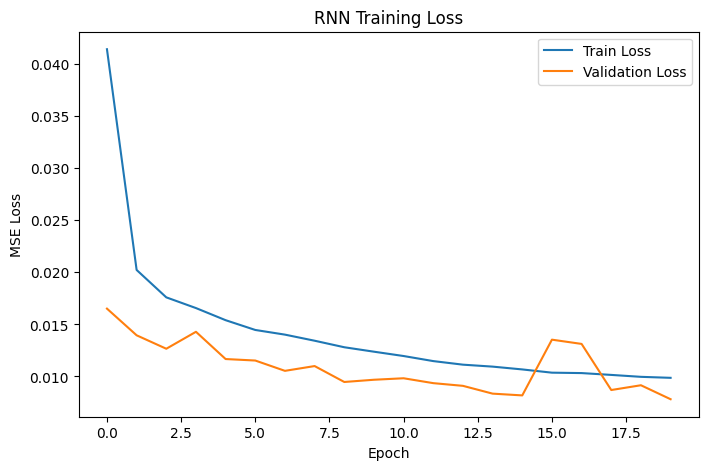

In [96]:
plt.figure(figsize=(8,5))
plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.title('RNN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

## LSTM

We will run LSTM for longer with early stopping.

In [97]:
from tensorflow.keras.callbacks import EarlyStopping


lstm_model = Sequential()
lstm_model.add(LSTM(64, input_shape=(SEQ_LEN, X.shape[2]), activation='tanh'))
# lstm_model.add(Dropout(0.2))  # The Dropout is optional to prevent overfitting
lstm_model.add(Dense(1))

lstm_model.compile(optimizer=Adam(0.001), loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',      # Monitor validation loss
    patience=5,              # Stop after 5 epochs of no improvement
    restore_best_weights=True # Keep the best model weights
)

# --------------------------
# Train the Model
# --------------------------
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=50,                # Train up to 50 epochs (will stop early if needed)
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

Epoch 1/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 29s 24ms/step - loss: 0.0524 - val_loss: 0.0158
Epoch 2/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 26s 24ms/step - loss: 0.0182 - val_loss: 0.0125
Epoch 3/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - loss: 0.0148 - val_loss: 0.0102
Epoch 4/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 25s 23ms/step - loss: 0.0130 - val_loss: 0.0087
Epoch 5/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.0119 - val_loss: 0.0088
Epoch 6/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.0109 - val_loss: 0.0080
Epoch 7/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - loss: 0.0101 - val_loss: 0.0080
Epoch 8/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - loss: 0.0094 - val_loss: 0.0075
Epoch 9/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - loss: 0.0093 - val_loss: 0.0079
Epoch 10/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - loss: 0.0087 - val_loss: 0.0065
Epoch 11/50
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 27s 25ms/step - loss: 0.0084 - val_loss: 0.0077
Epoch 12

KeyboardInterrupt: 

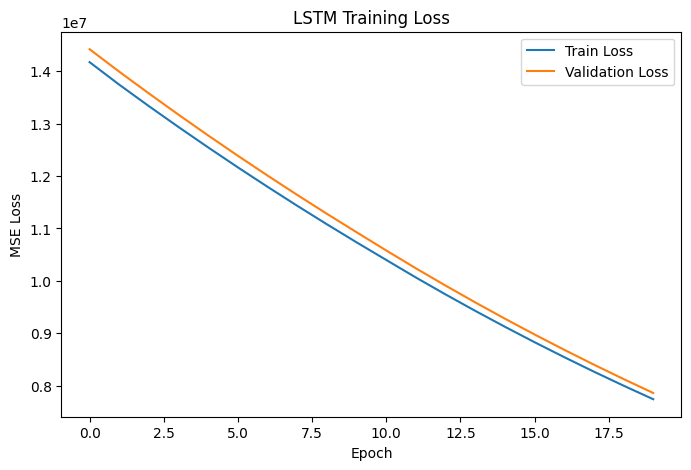

In [98]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history['loss'], label='Train Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

## Calculating Performance and Making Prediction

In [99]:
# RNN predictions
y_pred_rnn_scaled = rnn_model.predict(X_test)
y_pred_rnn = y_scaler.inverse_transform(y_pred_rnn_scaled)

# LSTM predictions
y_pred_lstm_scaled = lstm_model.predict(X_test)
y_pred_lstm = y_scaler.inverse_transform(y_pred_lstm_scaled)

# Unscaled values of Traffic
y_test_original = y_scaler.inverse_transform(y_test)

226/226 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
226/226 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step


In [100]:
from sklearn.metrics import mean_squared_error

# RNN MSE
mse_rnn = mean_squared_error(y_test_original, y_pred_rnn)
print(f"RNN Test MSE: {mse_rnn:.2f}")

# LSTM MSE
mse_lstm = mean_squared_error(y_test_original, y_pred_lstm)
print(f"LSTM Test MSE: {mse_lstm:.2f}")

RNN Test MSE: 373900.44
LSTM Test MSE: 327151.76


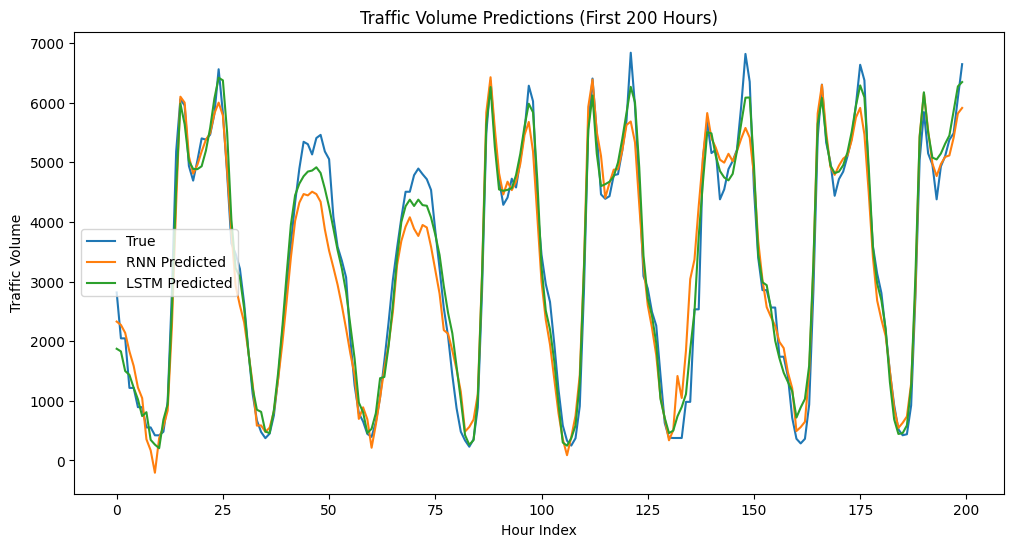

In [101]:
plt.figure(figsize=(12,6))
plt.plot(y_test_original[:200], label='True')
plt.plot(y_pred_rnn[:200], label='RNN Predicted')
plt.plot(y_pred_lstm[:200], label='LSTM Predicted')
plt.title('Traffic Volume Predictions (First 200 Hours)')
plt.xlabel('Hour Index')
plt.ylabel('Traffic Volume')
plt.legend()
plt.show()
